In [412]:
import os
import requests
import json
from dotenv import load_dotenv
# from langchain_openai import ChatOpenAI
from langchain_community.utilities.sql_database import SQLDatabase
# from langchain_experimental.sql import SQLDatabaseSequentialChain
# from langchain_community.utilities.sql_database import SQLDatabase
from langchain_core.prompts import MessagesPlaceholder, ChatPromptTemplate
from langchain_core.prompts import PromptTemplate
from typing_extensions import Annotated, TypedDict
from langchain_community.tools.sql_database.tool import QuerySQLDataBaseTool
# from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor
from langchain_openai import ChatOpenAI
import time 
import yaml
import json 
from langchain_community.agent_toolkits import JsonToolkit, create_json_agent
from langchain_community.tools.json.tool import JsonSpec
from langchain_openai import OpenAI
from langchain.tools import Tool
import openai 

In [413]:
THINGSBOARD_URL = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"
DASHBOARD_ID = "http://localhost:8080/tenants"

DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "thingsboard"
DB_USER = "thingsboard"
DB_PASSWORD = "postgres"


THINGSBOARD_HOST = "http://localhost:8080"
USERNAME = "tenant@thingsboard.org"
PASSWORD = "tenant"

load_dotenv()
openai_api_key = os.getenv('OPENAI_PROJECT_API_KEY')
client = openai.OpenAI(api_key=openai_api_key)
llm_model = "gpt-3.5-turbo"

In [414]:
# Load farm metadata 
with open("/Users/george/Documents/final_push/function-calling-for-sensors-at-the-edge/farm_model_small_v2.json", "r") as file:
    data = json.load(file)

In [415]:
# Authenticate with ThingsBoard
def authenticate():
    auth_url = f"{THINGSBOARD_URL}/api/auth/login"
    payload = {'username': USERNAME, 'password': PASSWORD}
    response = requests.post(auth_url, json=payload)
    response.raise_for_status()
    return response.json()['token']

In [416]:
jwt_token = authenticate()

In [417]:
# data

In [418]:
# create tool
tools = [
    {
        "type": "function",
        "function": {
            "name": "get_farm_details",
            "description": "Return details about a specific farm field as a JSON object.",
            "parameters": {
                "type": "object",
                "properties": {
                    "a": {
                        "type": "integer",
                        "description": "The index of the field to retrieve details for (0-based).",
                    },
                },
                "required": ["a"],
            },
        },
    }
]

In [419]:
def get_farm_details(a: int) -> str:
    """Return Farm field details as a JSON string

    Args:
        a: Field Index
    """
    try:
        field_data = data['farm']['fields'][a]
        return json.dumps(field_data)
    except IndexError:
        return json.dumps({"error": f"Field index {a} is out of bounds."})
    except KeyError:
        return json.dumps({"error": "The 'farm' or 'fields' key was not found in the data."})
    except Exception as e:
        return json.dumps({"error": f"An error occurred: {e}"})

In [420]:
# def sensor_extraction_agent(query):
#     """Runs a conversation with the LLM that can call the get_farm_details tool."""
#     messages = [
#         {"role": "system", "content": "You are a helpful assistant that identifies relevant devices (sensor_list) mentioned in the user's request and returns them as a JSON array of their IDs e.g. If no specific devices are mentioned, return an empty JSON array."
#         "F001 is North Field,"
#         "F002 is Northeast Field"
#         "F003 is East Field"
#         "F004 is Southeast Field"
#         "F005 is South Field"
#         "F006 is Southwest Field"
#         "F007 is West Field"
#         "F008 is Northwest Field"
#         "F009 is Central Field"
#         "Note: if the right Field is not provided return an empty json"
#         },
     
#         {"role": "user", "content": query}
#     ]

#     response = client.chat.completions.create(
#         model="gpt-3.5-turbo",
#         messages=messages,
#         tools=tools,
#         tool_choice="auto", 
#     )

#     response_message = response.choices[0].message

#     if response_message.tool_calls:
#         print("LLM initiated a tool call:")
#         # print(response_message.tool_calls)

#         tool_call = response_message.tool_calls[0]
#         function_name = tool_call.function.name
#         function_to_call = globals()[function_name]
#         function_args = json.loads(tool_call.function.arguments)
#         function_response = function_to_call(**function_args)

#         # Logging 
#         # print(f"Calling function '{function_name}' with arguments: {function_args}")
#         # print(f"Function returned: {function_response}")

#         messages.append(response_message)
#         messages.append(
#             {
#                 "tool_call_id": tool_call.id,
#                 "role": "tool",
#                 "name": function_name,
#                 "content": function_response,
#             }
#         )
#         second_response = client.chat.completions.create(
#             # model="gpt-3.5-turbo-0613",
#             model="gpt-3.5-turbo",
#             messages=messages,
#         )
        
#         return second_response.choices[0].message.content
#     else:
#         # If no tool call, the LLM might be directly answering based on the system prompt
#         try:
#             # Attempt to parse the response as JSON (assuming it followed the system prompt)
#             return json.loads(response_message.content)
#         except (json.JSONDecodeError, TypeError):
#             # If it's not valid JSON, return the raw content
#             return response_message.content

In [421]:
# def sensor_extraction_agent(query):
#     messages = [
#         {
#             "role": "system",
#             "content": (
#                 "You are a helpful assistant that identifies relevant devices (sensor_list) mentioned in the user's "
#                 "request and returns them as a JSON array of their IDs. "
#                 "Field mappings: F001 is North Field, F002 is Northeast Field, F003 is East Field, "
#                 "F004 is Southeast Field, F005 is South Field, F006 is Southwest Field, "
#                 "F007 is West Field, F008 is Northwest Field, F009 is Central Field. "
#                 "If the right field is not provided, return an empty JSON array."
#             ),
#         },
#         {"role": "user", "content": query},
#     ]

#     response = client.chat.completions.create(
#         model="gpt-3.5-turbo",
#         messages=messages,
#         tools=tools,
#         tool_choice="auto",
#     )

#     response_message = response.choices[0].message

#     if hasattr(response_message, 'tool_calls') and response_message.tool_calls:
#         tool_responses = []

#         for tool_call in response_message.tool_calls:
#             function_name = tool_call.function.name
#             function_to_call = globals().get(function_name)
#             if not function_to_call:
#                 continue  # Skip if the function is not defined

#             function_args = json.loads(tool_call.function.arguments)
#             function_response = function_to_call(**function_args)

#             tool_responses.append({
#                 "tool_call_id": tool_call.id,
#                 "role": "tool",
#                 "name": function_name,
#                 "content": function_response,
#             })

#         # Append the assistant's message and all tool responses to the message history
#         messages.append(response_message)
#         messages.extend(tool_responses)

#         # Send the updated message history back to the model
#         second_response = client.chat.completions.create(
#             model="gpt-3.5-turbo",
#             messages=messages,
#         )

#         return second_response.choices[0].message.content
#     else:
#         # If no tool call, attempt to parse the response as JSON
#         try:
#             return json.loads(response_message.content)
#         except (json.JSONDecodeError, TypeError):
#             return response_message.content


In [439]:
def sensor_extraction_agent(query):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful assistant that identifies all relevant sensors mentioned in the user's request "
                "and returns them as a JSON array of their IDs, in this format: "
                '{"sensors": ["TEMP-0100", "TEMP-0700", ...]}. '
                "Match the user's field names to the following mappings:\n"
                "- F001: North Field\n"
                "- F002: Northeast Field\n"
                "- F003: East Field\n"
                "- F004: Southeast Field\n"
                "- F005: South Field\n"
                "- F006: Southwest Field\n"
                "- F007: West Field\n"
                "- F008: Northwest Field\n"
                "- F009: Central Field\n"
                "Extract sensors only from the fields mentioned. If no valid field is provided, return an empty JSON array.Do not hallucinate sensor device"
            ),
        },
        {"role": "user", "content": query},
    ]


    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        tools=tools,
        tool_choice="auto",
    )

    response_message = response.choices[0].message

    if hasattr(response_message, 'tool_calls') and response_message.tool_calls:
        tool_responses = []

        for tool_call in response_message.tool_calls:
            function_name = tool_call.function.name
            function_to_call = globals().get(function_name)
            if not function_to_call:
                continue  # Skip if the function is not defined

            function_args = json.loads(tool_call.function.arguments)
            function_response = function_to_call(**function_args)

            tool_responses.append({
                "tool_call_id": tool_call.id,
                "role": "tool",
                "name": function_name,
                "content": function_response,
            })

        # Append the assistant's message and all tool responses to the message history
        messages.append(response_message)
        messages.extend(tool_responses)

        # Send the updated message history back to the model
        second_response = client.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=messages,
        )

        return second_response.choices[0].message.content
    else:
        # If no tool call, attempt to parse the response as JSON
        try:
            return json.loads(response_message.content)
        except (json.JSONDecodeError, TypeError):
            return response_message.content

In [440]:
# field_name = "North Field and South Field"
# sensor_type = "temperature, humilidty, camera"
# query = f"What is the {sensor_type} at {field_name}?"
# query = "Get me all sensors in the North Field and South Field"
# query = "Get me all sensors in North Field and West Field"
# query = "Get me temperature sensors in North Field and West Field"
query = "Get me temperature sensors in South Field"
query
result = sensor_extraction_agent(query)
print(result)
clean_output = json.loads(result)
# clean_output

{"sensors": []}


In [434]:
result

'{"sensors": ["TEMP-0500"]}'

In [424]:
# 2. Get device ID by name
def get_device_id_by_name(device_name, token):
    headers = {
        "Content-Type": "application/json",
        "X-Authorization": f"Bearer {token}"
    }
    url = f"{THINGSBOARD_URL}/api/tenant/devices?deviceName={device_name}"
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    device = response.json()
    return device['id']['id'] if device else None

In [425]:
def get_device_keys(jwt_token, device_id):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/keys/timeseries"
    headers = {
        "X-Authorization": f"Bearer {jwt_token}"
    }

    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json()  # Returns a list of key names
    else:
        return {
            "error": f"Failed to fetch keys: {response.status_code}",
            "details": response.text
        }

In [426]:
sensor_ids = clean_output['sensors'][0]
sensor_ids

'TEMP-0500'

In [427]:
# change the device name 
device_name = sensor_ids 
sensor_id = get_device_id_by_name(device_name, jwt_token)
device_id = sensor_id
sensor_id

'e82fc1b0-1221-11f0-a236-5f0808fc8cdf'

In [428]:
device_key = get_device_keys(jwt_token, sensor_id)
device_key[-1]

'temp'

In [429]:
# Last 24 hours timestamps
end_ts = int(time.time() * 1000)  
start_ts = end_ts - (340 * 60 * 60 * 1000)  # 24 hours ago

# keys = "temperature"  
keys = device_key

In [430]:
def get_historical_data(jwt_token, device_id, start_ts, end_ts, keys):
    url = f"{THINGSBOARD_URL}/api/plugins/telemetry/DEVICE/{device_id}/values/timeseries"
    params = {"keys": keys, "startTs": start_ts, "endTs": end_ts, "limit": 100}
    headers = {"X-Authorization": f"Bearer {jwt_token}"}
    
    response = requests.get(url, headers=headers, params=params)
    return response.json() if response.status_code == 200 else {"error": "Failed to fetch telemetry data"}

response = get_historical_data(jwt_token, device_id, start_ts, end_ts, keys)
response

{'deviceId': [{'ts': 1743869011403, 'value': 'TEMP-0500'},
  {'ts': 1743868709415, 'value': 'TEMP-0500'},
  {'ts': 1743868407223, 'value': 'TEMP-0500'},
  {'ts': 1743868105251, 'value': 'TEMP-0500'},
  {'ts': 1743867803070, 'value': 'TEMP-0500'},
  {'ts': 1743867501220, 'value': 'TEMP-0500'},
  {'ts': 1743867199515, 'value': 'TEMP-0500'},
  {'ts': 1743866897596, 'value': 'TEMP-0500'},
  {'ts': 1743866595362, 'value': 'TEMP-0500'},
  {'ts': 1743866293508, 'value': 'TEMP-0500'},
  {'ts': 1743865991358, 'value': 'TEMP-0500'},
  {'ts': 1743864788511, 'value': 'TEMP-0500'}],
 'unit': [{'ts': 1743869011403, 'value': 'degC'},
  {'ts': 1743868709415, 'value': 'degC'},
  {'ts': 1743868407223, 'value': 'degC'},
  {'ts': 1743868105251, 'value': 'degC'},
  {'ts': 1743867803070, 'value': 'degC'},
  {'ts': 1743867501220, 'value': 'degC'},
  {'ts': 1743867199515, 'value': 'degC'},
  {'ts': 1743866897596, 'value': 'degC'},
  {'ts': 1743866595362, 'value': 'degC'},
  {'ts': 1743866293508, 'value': 'deg

In [431]:
# telemetry_data = response['temp']
telemetry_data

{'deviceId': [{'ts': 1744725273796, 'value': 'TEMP-0100'}],
 'unit': [{'ts': 1744725374405, 'value': 'degC'}],
 'temp': [{'ts': 1744725356013, 'value': '31.933204571888812'}]}

In [432]:
telemetry_data = response
telemetry_data['temp']

[{'ts': 1743869011403, 'value': '27.320302266151312'},
 {'ts': 1743868709415, 'value': '31.306305009158017'},
 {'ts': 1743868407223, 'value': '33.48834158762985'},
 {'ts': 1743868105251, 'value': '34.10189227675727'},
 {'ts': 1743867803070, 'value': '28.534077498339663'},
 {'ts': 1743867501220, 'value': '27.817652246517067'},
 {'ts': 1743867199515, 'value': '32.49147749209336'},
 {'ts': 1743866897596, 'value': '28.854327077358164'},
 {'ts': 1743866595362, 'value': '28.009212122493373'},
 {'ts': 1743866293508, 'value': '31.45880622072238'},
 {'ts': 1743865991358, 'value': '33.49596248476476'},
 {'ts': 1743864788511, 'value': '25.02549472745727'}]

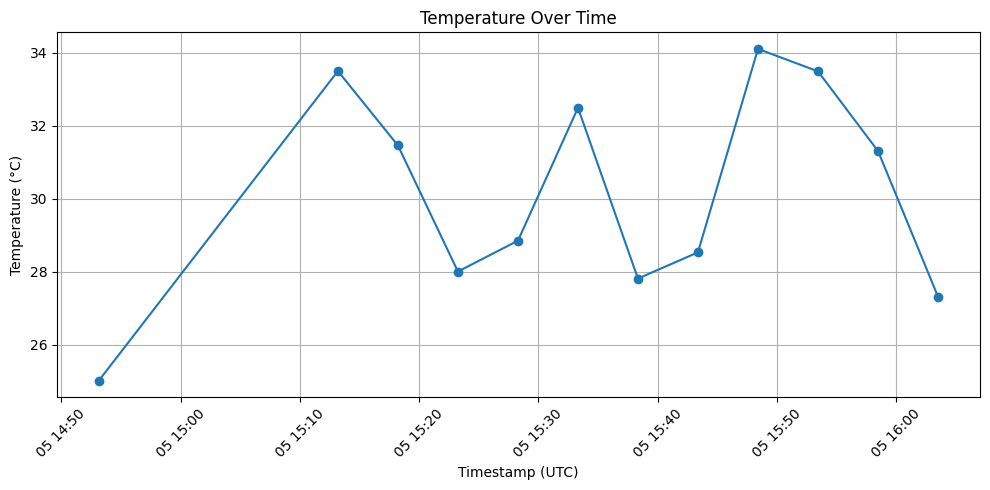

In [433]:
import pandas as pd
import os
from datetime import datetime, timezone
import matplotlib.pyplot as plt

os.environ['MPLCONFIGDIR'] = '/Users/george/.config/matplotlib'

# Only process 'temp' data
data = []
for entry in telemetry_data.get('temp', []):
    data.append({
        'timestamp': datetime.fromtimestamp(entry['ts'] / 1000, tz=timezone.utc),
        'temperature': float(entry['value'])
    })

df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 5))
plt.plot(df['timestamp'], df['temperature'], marker='o')
plt.xlabel('Timestamp (UTC)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


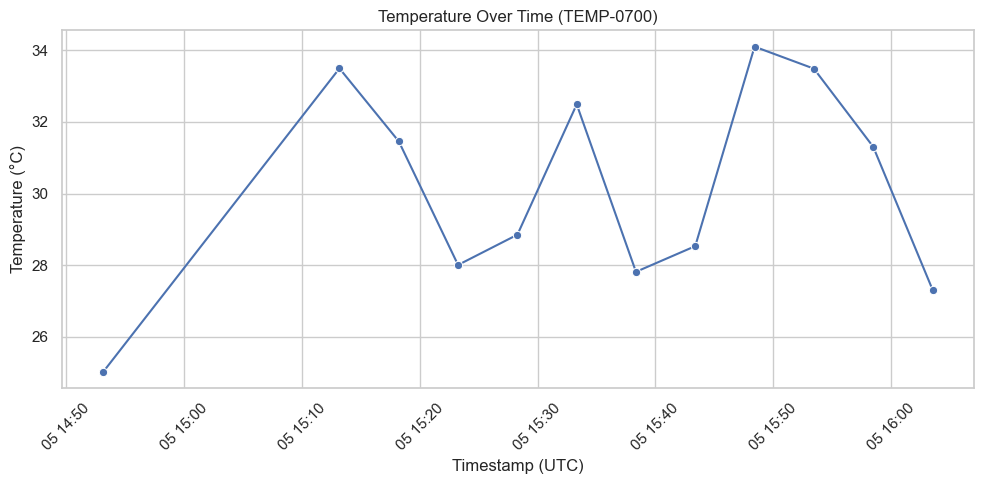

In [441]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime, timezone
import os

os.environ['MPLCONFIGDIR'] = '/Users/george/.config/matplotlib'

# Assuming telemetry_data is defined as the dictionary you posted
# telemetry_data = {
#     'deviceId': [{'ts': 1743869018853, 'value': 'TEMP-0700'}, ...],  # insert full dict
#     'unit': [{'ts': 1743869018853, 'value': 'degC'}, ...],
#     'temp': [{'ts': 1743869018853, 'value': '34.758302935443'}, ...]
# }

# Extract 'temp' data only
data = []
for entry in telemetry_data.get('temp', []):
    data.append({
        'timestamp': datetime.fromtimestamp(entry['ts'] / 1000, tz=timezone.utc),
        'temperature': float(entry['value'])
    })

df = pd.DataFrame(data)

# Plotting with seaborn
sns.set(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.lineplot(data=df, x='timestamp', y='temperature', marker='o')

plt.xlabel('Timestamp (UTC)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Over Time (TEMP-0700)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/bw/zwn916250j389j86x0z9f6tr0000gn/T/ipykernel_91544/3780151913.py:57: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/bw/zwn916250j389j86x0z9f6tr0000gn/T/ipykernel_91544/3780151913.py:57: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/george/Documents/final_push/function-calling-for-sensors-at-the-edge/llm/env3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127777 (\N{THERMOMETER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/george/Documents/final_push/function-calling-for-sensors-at-the-edge/llm/env3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


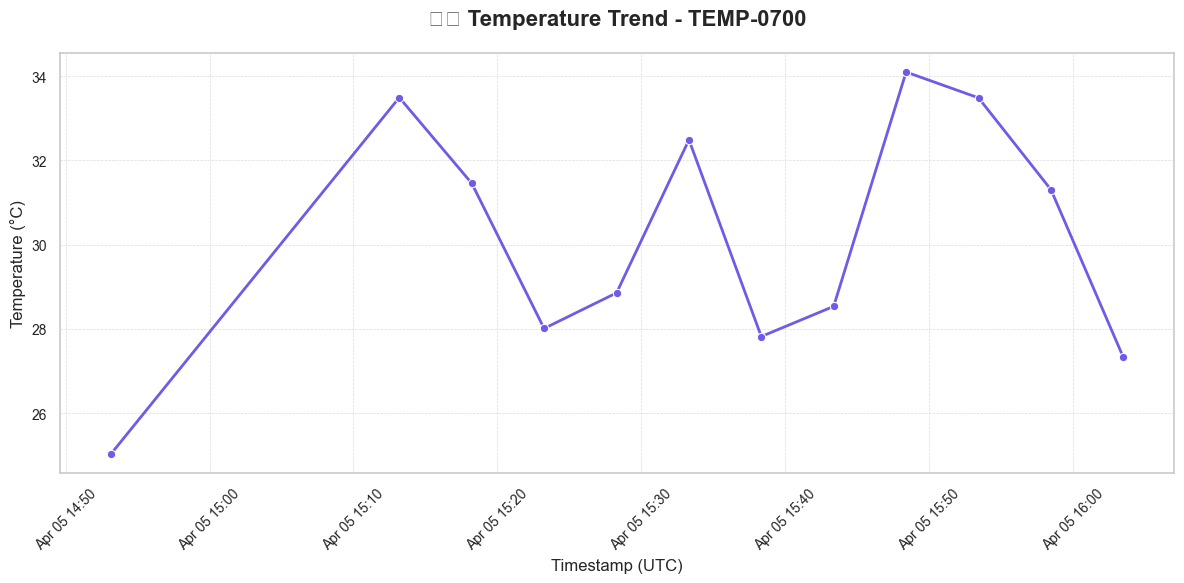

In [442]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
import os

os.environ['MPLCONFIGDIR'] = '/Users/george/.config/matplotlib'

# Replace with your full telemetry data
# telemetry_data = {
#     'deviceId': [{'ts': 1743869018853, 'value': 'TEMP-0700'}, ...],  # insert full dict
#     'unit': [{'ts': 1743869018853, 'value': 'degC'}, ...],
#     'temp': [{'ts': 1743869018853, 'value': '34.758302935443'}, ...]
# }

# Extract 'temp' data
data = []
for entry in telemetry_data.get('temp', []):
    data.append({
        'timestamp': datetime.fromtimestamp(entry['ts'] / 1000, tz=timezone.utc),
        'temperature': float(entry['value'])
    })

df = pd.DataFrame(data)

# Apply a nice seaborn theme
sns.set_theme(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x='timestamp',
    y='temperature',
    marker='o',
    linewidth=2,
    markersize=6,
    color="#6C5CE7"  # a clean purple tone
)

# Format the x-axis timestamps
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d %H:%M', tz=timezone.utc))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())

# Labels and title with nice spacing
plt.title('🌡️ Temperature Trend - TEMP-0700', fontsize=16, weight='bold', pad=20)
plt.xlabel('Timestamp (UTC)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)

# Rotate x-ticks and style them
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# Tight layout and subtle grid
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.show()


In [109]:
result

'{}'

In [133]:
# Extract sensors for multiple fields
def extract_sensors_for_fields(query):
    messages = [
        {
            "role": "system",
            "content": (
                "You are a helpful assistant that identifies relevant devices (sensor_list) mentioned in the user's "
                "request and returns them as a JSON object mapping each field to its list of sensor IDs. "
                "Field mappings: F001 is North Field, F002 is Northeast Field, F003 is East Field, "
                "F004 is Southeast Field, F005 is South Field, F006 is Southwest Field, "
                "F007 is West Field, F008 is Northwest Field, F009 is Central Field. "
                "If no valid fields are provided, return an empty JSON object."
            ),
        },
        {"role": "user", "content": query},
    ]

    # response = llm.chat(messages)
    response = client.chat.completions.create(
        model="gpt-3.5-turbo",
        messages=messages,
        tools=tools,
        tool_choice="auto",
    )
    print(response)
    try:
        field_sensor_mapping = json.loads(response.content)
    except (json.JSONDecodeError, TypeError):
        return {"error": "Invalid response from LLM", "content": response.content}

    return field_sensor_mapping

# Retrieve sensor data for multiple fields
def get_sensor_data_for_fields(query, sensor_type):
    field_sensor_mapping = extract_sensors_for_fields(query)
    if "error" in field_sensor_mapping:
        return field_sensor_mapping

    results = {}
    for field_name, sensor_ids in field_sensor_mapping.items():
        field_results = []
        for sensor_id in sensor_ids:
            device_id = get_device_id_by_name(sensor_id)
            if not device_id:
                field_results.append({"sensor_id": sensor_id, "error": "Device ID not found"})
                continue

            device_keys = get_device_keys(device_id)
            if "error" in device_keys:
                field_results.append({"sensor_id": sensor_id, "error": device_keys["error"]})
                continue

            if sensor_type not in device_keys:
                field_results.append({"sensor_id": sensor_id, "error": f"Sensor type '{sensor_type}' not found"})
                continue

            end_ts = int(time.time() * 1000)
            start_ts = end_ts - (24 * 60 * 60 * 1000)  # Last 24 hours

            historical_data = get_historical_data(device_id, start_ts, end_ts, sensor_type)
            field_results.append({"sensor_id": sensor_id, "data": historical_data})

        results[field_name] = field_results

    return results

In [134]:
field_name = "North Field"
sensor_type = "temperature, humilidty, camera"
query = f"What is the {sensor_type} at {field_name}?"
query
result = extract_sensors_for_fields(query)
result

ChatCompletion(id='chatcmpl-BNOMAieSaQmBxJ9HbuEegXsf3QyQJ', choices=[Choice(finish_reason='tool_calls', index=0, logprobs=None, message=ChatCompletionMessage(content=None, refusal=None, role='assistant', annotations=[], audio=None, function_call=None, tool_calls=[ChatCompletionMessageToolCall(id='call_3hHdi0v2QizAXyUaDKO9duI6', function=Function(arguments='{"a":1}', name='get_farm_details'), type='function')]))], created=1744914870, model='gpt-3.5-turbo-0125', object='chat.completion', service_tier='default', system_fingerprint=None, usage=CompletionUsage(completion_tokens=17, prompt_tokens=188, total_tokens=205, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0)))


AttributeError: 'ChatCompletion' object has no attribute 'content'